In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from torchvision.datasets import Flowers102
from transformers import AutoImageProcessor

In [2]:
MODEL_NAME = "google/vit-base-patch16-224-in21k"
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
print(processor)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



In [3]:
class HFProcessorTransform:
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, image):
        inputs = self.processor(image, return_tensors="pt")
        return inputs["pixel_values"].squeeze(0)

transform = HFProcessorTransform(processor)

In [4]:
train_dataset = Flowers102(root="../data", split="train", download=True, transform=transform)
val_dataset   = Flowers102(root="../data", split="val",   download=True, transform=transform)
test_dataset  = Flowers102(root="../data", split="test",  download=True, transform=transform)

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

img, label = train_dataset[0]
print(f"Image shape: {img.shape}")
print(f"Label: {label}")

100%|██████████| 345M/345M [03:01<00:00, 1.90MB/s] 
100%|██████████| 502/502 [00:00<00:00, 267kB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 7.34MB/s]


Train: 1020
Val:   1020
Test:  6149
Image shape: torch.Size([3, 224, 224])
Label: 0


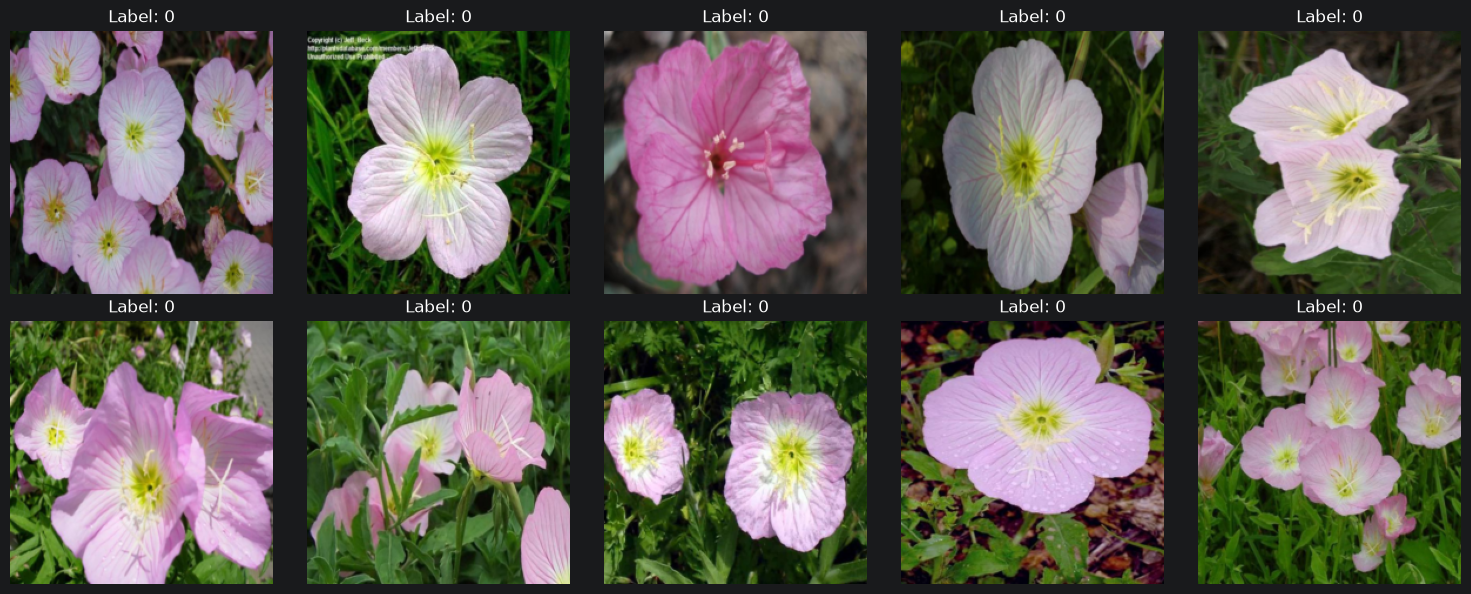

In [5]:
def denormalize(tensor):
    # Pull the mean/std the processor is actually using
    mean = torch.tensor(processor.image_mean).view(3, 1, 1)
    std = torch.tensor(processor.image_std).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    img = denormalize(img).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
counts = Counter(labels)
print(f"Classes present: {len(counts)}")
print(f"Images per class (min/max/avg): "
      f"{min(counts.values())}/{max(counts.values())}/{np.mean(list(counts.values())):.1f}")

Classes present: 102
Images per class (min/max/avg): 10/10/10.0
